# Data blocking

In this notebook I inspect the output of one strain-stress simulation with MACE potential, inspect the output, demonstrate data-blocking, and fix the analysis pipeline.

In [1]:
!which python

/bin/bash: /home/gabri/anaconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)
/home/gabri/anaconda3/bin/python


In [2]:
import numpy as np
import pandas as pd

from lammps_logfile import read_log

import matplotlib.pyplot as plt

from ase.io import write
import os

## Load data

Load and check everything is as expected.

## Structural analysis

I have to find a good order parameter to determine phase transition

In [3]:
from ase.io import Trajectory

In [5]:
from structural_analysis import *

DUMPDIR="../OUTPUT_LOCAL/DUMP"

files = os.listdir(DUMPDIR)
files = [f for f in files if f.endswith(".traj")]

trajs = [Trajectory(os.path.join(DUMPDIR, f)) for f in files]    

In [13]:
results = count_boundary_dir(DUMPDIR, cutoff=1.7, skin=0.1, threshold=3, max_workers=16)

Processing file: ../OUTPUT_LOCAL/DUMP/85.trajProcessing file: ../OUTPUT_LOCAL/DUMP/27.trajProcessing file: ../OUTPUT_LOCAL/DUMP/16.traj

Processing:   0%|          | 0/100 [00:00<?, ?it/s]

Processing file: ../OUTPUT_LOCAL/DUMP/73.trajProcessing file: ../OUTPUT_LOCAL/DUMP/33.trajProcessing file: ../OUTPUT_LOCAL/DUMP/63.trajProcessing file: ../OUTPUT_LOCAL/DUMP/86.trajProcessing file: ../OUTPUT_LOCAL/DUMP/28.traj
Processing file: ../OUTPUT_LOCAL/DUMP/38.trajProcessing file: ../OUTPUT_LOCAL/DUMP/53.trajProcessing file: ../OUTPUT_LOCAL/DUMP/69.trajProcessing file: ../OUTPUT_LOCAL/DUMP/95.trajProcessing file: ../OUTPUT_LOCAL/DUMP/0.trajProcessing file: ../OUTPUT_LOCAL/DUMP/40.trajProcessing file: ../OUTPUT_LOCAL/DUMP/62.trajProcessing file: ../OUTPUT_LOCAL/DUMP/8.traj














Processing file: ../OUTPUT_LOCAL/DUMP/47.traj
Processing file: ../OUTPUT_LOCAL/DUMP/19.traj
Processing file: ../OUTPUT_LOCAL/DUMP/3.traj
Processing file: ../OUTPUT_LOCAL/DUMP/7.traj
Processing file: ../OUTPUT_LOCAL/DUMP/34.traj
Processing file: ../OUTPUT_LOCAL/DUMP/80.traj


Processing:   1%|          | 1/100 [02:09<3:33:10, 129.20s/it]

Processing file: ../OUTPUT_LOCAL/DUMP/87.traj
Processing file: ../OUTPUT_LOCAL/DUMP/65.traj
Processing file: ../OUTPUT_LOCAL/DUMP/45.traj
Processing file: ../OUTPUT_LOCAL/DUMP/24.traj
Processing file: ../OUTPUT_LOCAL/DUMP/90.traj
Processing file: ../OUTPUT_LOCAL/DUMP/43.traj
Processing file: ../OUTPUT_LOCAL/DUMP/97.traj


...

Processing:  80%|████████  | 80/100 [11:49<01:40,  5.03s/it]

Processing file: ../OUTPUT_LOCAL/DUMP/68.traj
Processing file: ../OUTPUT_LOCAL/DUMP/96.traj


Processing:  81%|████████  | 81/100 [13:01<04:08, 13.06s/it]

Processing file: ../OUTPUT_LOCAL/DUMP/76.traj
Processing file: ../OUTPUT_LOCAL/DUMP/93.traj
Processing file: ../OUTPUT_LOCAL/DUMP/99.traj


Processing:  99%|█████████▉| 99/100 [13:49<00:08,  8.38s/it]


(0.0, 25.0)

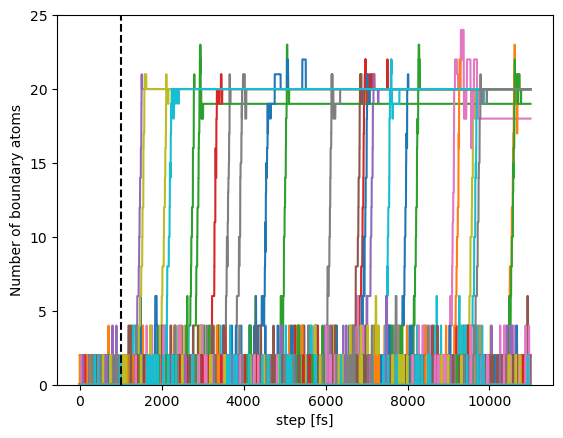

In [14]:
for filename, value in results.items():
    plt.plot(value["counts"], label=filename)

plt.vlines(1000, 0, 100, colors="k", linestyles="dashed", label = "Strain 0.21")
plt.xlabel("step [fs]")
plt.ylabel("Number of boundary atoms")
plt.ylim(0, 25)

#plt.legend()

In [15]:
for filename, value in results.items():
    print(f"{filename}: {value['updates']} neighbor list updates")

85.traj: 1585 neighbor list updates
63.traj: 1590 neighbor list updates
16.traj: 1849 neighbor list updates
86.traj: 1842 neighbor list updates
33.traj: 1550 neighbor list updates
28.traj: 1565 neighbor list updates
53.traj: 1570 neighbor list updates
95.traj: 1830 neighbor list updates
38.traj: 1560 neighbor list updates
69.traj: 1550 neighbor list updates
0.traj: 1840 neighbor list updates
27.traj: 1570 neighbor list updates
73.traj: 1548 neighbor list updates
8.traj: 1574 neighbor list updates
40.traj: 1869 neighbor list updates
62.traj: 1593 neighbor list updates
47.traj: 1569 neighbor list updates
19.traj: 1567 neighbor list updates
3.traj: 1801 neighbor list updates
7.traj: 1565 neighbor list updates
34.traj: 1590 neighbor list updates
80.traj: 1572 neighbor list updates
87.traj: 1811 neighbor list updates
65.traj: 1575 neighbor list updates
45.traj: 1556 neighbor list updates
24.traj: 1587 neighbor list updates
90.traj: 1808 neighbor list updates
43.traj: 1837 neighbor list upda

In [16]:
import json

class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super(NpEncoder, self).default(obj)

COUNTSFILE="LONG_COUNTS.json"
with open(COUNTSFILE, "w") as f:
    json.dump(results, f, cls=NpEncoder, indent=4)

In [17]:
INITIAL_STEP = 1000
timestep = 0.001

breaking_steps = np.array([find_breaking_step(value['counts']) for value in results.values()])

ncensored = np.sum(breaking_steps == None)
breaking_steps = breaking_steps[breaking_steps != None]
breaking_steps -= INITIAL_STEP
breaking_steps = timestep * breaking_steps

print(breaking_steps)

[1.7870000000000001 5.955 2.6590000000000003 6.992 6.17 8.614 1.925
 8.136000000000001 5.15 2.348 1.114 6.018 4.055 2.962 8.691 9.598 7.259
 0.512 0.581 3.7600000000000002 8.259 9.61 5.84 1.245 6.573 8.776]


In [18]:
import numpy as np
import emcee

# -------------------------------------------------
# Log likelihood for exponential waiting times
# -------------------------------------------------

def log_likelihood(theta, events, n_censored, Tmax):

    k = theta[0]

    if k <= 0:
        return -np.inf

    logL_events = np.sum(np.log(k) - k * events)

    logL_censored = -k * Tmax * n_censored

    return logL_events + logL_censored


# -------------------------------------------------
# Prior on rate
# -------------------------------------------------

def log_prior(theta, kmin=1e-12, kmax=1e12):
    k = theta[0]

    if kmin < k < kmax:
        return 0.0
    return -np.inf


def log_posterior(theta, events, n_censored, Tmax):

    lp = log_prior(theta)

    if not np.isfinite(lp):
        return -np.inf

    return lp + log_likelihood(theta, events, n_censored, Tmax)


# -------------------------------------------------
# Run MCMC inference
# -------------------------------------------------

def infer_rate(data, ncensored, Tmax, nwalkers=32, nsteps=5000):

    ndim = 1

    # initial guess from MLE
    k_guess = 1.0 / np.mean(data)

    pos = k_guess * (1 + 1e-2 * np.random.randn(nwalkers, ndim))

    sampler = emcee.EnsembleSampler(
        nwalkers,
        ndim,
        log_posterior,
        args=(data, ncensored, Tmax)
    )

    sampler.run_mcmc(pos, nsteps, progress=True)

    return sampler


# -------------------------------------------------
# Convert rate samples -> energy barrier samples
# -------------------------------------------------

def rate_to_barrier(k_samples, beta, A):

    DeltaE_samples = -(1/beta) * np.log(k_samples / A)

    return DeltaE_samples


# -------------------------------------------------
# Main analysis function
# -------------------------------------------------

def analyze_transitions(data, ncensored, Tmax, temperature, A):

    kB = 8.617333262e-5  # eV/K
    beta = 1.0 / (kB * temperature)

    sampler = infer_rate(data, ncensored, Tmax)

    burnin = int(0.3 * sampler.iteration)

    samples = sampler.get_chain(discard=burnin, flat=True)

    k_samples = samples[:,0]

    DeltaE_samples = rate_to_barrier(k_samples, beta, A)

    # statistics
    k_mean = np.mean(k_samples)
    k_std = np.std(k_samples)

    E_mean = np.mean(DeltaE_samples)
    E_std = np.std(DeltaE_samples)

    print("Rate k:")
    print(f"mean = {k_mean:.3e}")
    print(f"std  = {k_std:.3e}")

    print("\nEnergy barrier ΔE (eV):")
    print(f"mean = {E_mean:.3f}")
    print(f"std  = {E_std:.3f}")

    return k_samples, DeltaE_samples

In [19]:
ksamples, DeltaE_samples = analyze_transitions(breaking_steps, ncensored=ncensored, Tmax=10, temperature=300, A=1e15)

100%|██████████| 5000/5000 [00:02<00:00, 2333.05it/s]

Rate k:
mean = 3.088e-02
std  = 5.947e-03

Energy barrier ΔE (eV):
mean = 0.983
std  = 0.005


95% credible interval for k: [0.020, 0.044] eV
Average time to decay: 5.177 fs
Number of decays observed: 26
Rate from average time: 0.193 1/fs


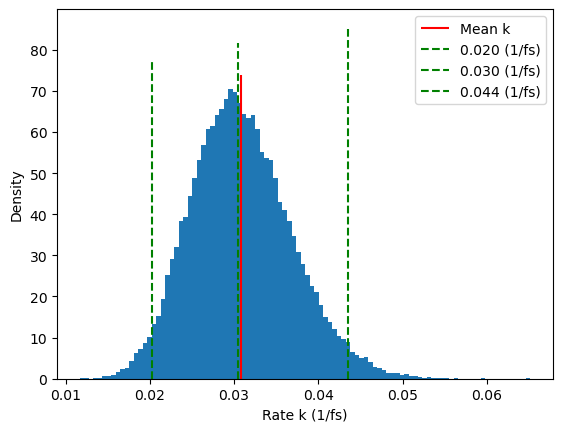

In [36]:
quantiles = np.percentile(ksamples, [2.5, 50, 97.5])
kmean = np.mean(ksamples)
kstd = np.std(ksamples)
Emean = np.mean(DeltaE_samples)
Estd = np.std(DeltaE_samples)
print(f"95% credible interval for k: [{quantiles[0]:.3f}, {quantiles[2]:.3f}] eV")

plt.hist(ksamples, bins=100, density=True)
plt.vlines(np.mean(ksamples), 0, plt.gca().get_ylim()[1], colors="r", label="Mean k")
for q in quantiles:
    plt.vlines(q, 0, plt.gca().get_ylim()[1], colors="g", linestyles="dashed", label=f"{q:.3f} (1/fs)")
plt.xlabel("Rate k (1/fs)")
plt.ylabel("Density")
plt.legend()

with open("local_rate_stats.json", "w") as f:
    json.dump({
        "k_mean": kmean,
        "k_std": kstd,
        "E_mean": Emean,
        "E_std": Estd,
    }, f, indent=4)

ndecays = len(breaking_steps)
average_time = np.mean(breaking_steps)
print(f"Average time to decay: {average_time:.3f} fs")
print(f"Number of decays observed: {ndecays}")
print(f"Rate from average time: {1/average_time:.3f} 1/fs")